# Taller 1: Perceptrón Simple y Red Adaline
**Maestría en Ciencias de la Información y las Comunicaciones (MCIC)**  
**Universidad Distrital Francisco José de Caldas**  
**Asignatura:** Inteligencia Computacional Aplicada  
**Docente:** Cesar Andrey Perdomo Charry  
**Estudiante:** Juan Felipe Rodríguez Galindo (Código: 20261595004)  

---

### Objetivos del Taller
1. Desarrollar e implementar en Python modelos de **Perceptrón Simple** y neurona lineal adaptable (**Adaline**) de una sola capa y una sola neurona.
2. Parametrizar completamente los modelos (número de entradas, umbral de activación $\theta$, tasa de aprendizaje $\alpha$, reglas de actualización de pesos).
3. Evaluar la capacidad de aprendizaje ante problemas canónicos linealmente separables (compuertas lógicas AND y OR de 2, 3 y 4 entradas).
4. Experimentar con conjuntos de datos continuos y multidimensionales:
   - **Dataset Iris** (separación de clase linealmente separable *Iris Setosa* vs. otras).
   - **Dataset Banknote Authentication** (autenticación de billetes bancarios a partir de características Wavelet).
5. Analizar el impacto de diferentes particiones de entrenamiento y prueba (60-40, 70-30, 80-20, 90-10) y variaciones de la tasa de aprendizaje $\alpha$.
6. Comparar de manera rigurosa los mecanismos de aprendizaje, convergencia, función de costo y robustez entre el Perceptrón Simple y Adaline.

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Configuración visual de las gráficas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['font.size'] = 10

print("Librerías importadas exitosamente.")

Librerías importadas exitosamente.


---
## Parte I: Perceptrón Simple

### 1. Marco Teórico y Formulación Matemática (Puntos 1 y 2)
El modelo de **Perceptrón Simple** de Rosenblatt consta de un vector de entradas aumentado con el término de polarización (*bias*) constante $x_0 = 1$:
$$X = [1, x_1, x_2, \dots, x_n]^T, \quad W = [w_0, w_1, w_2, \dots, w_n]^T$$

La combinación lineal ponderada (*net input*) se define como:
$$z = W^T X = w_0 + \sum_{i=1}^n w_i x_i$$

La función de activación es la función escalón unitario (*Step Function*):
$$Y(x) = \begin{cases} 1 & \text{si } z \ge \theta \\ 0 & \text{si } z < \theta \end{cases}$$
donde $\theta$ es el umbral de activación parametrizable (por defecto $\theta = 0$, absorbiéndose en el sesgo $w_0$).

#### Reglas de Corrección de Pesos Solicitadas:
El ajuste de pesos se realiza de acuerdo a:
$$W_i^* = W_i + \Delta W_i$$

Se implementan las 3 variantes solicitadas en el taller:
1. **Regla 1:** $\Delta W_i = d(x) \cdot X_i$  
   *Ajuste aditivo dependiente únicamente de la salida deseada y la entrada. No castiga los falsos positivos ($Y=1, d=0$), por lo que los pesos crecen monótonamente.*
2. **Regla 2:** $\Delta W_i = [d(x) - Y(x)] \cdot X_i$  
   *Regla clásica del Perceptrón con factor de aprendizaje unitario ($\alpha = 1$). Modifica los pesos en dirección al gradiente del error discreto.*
3. **Regla 3:** $\Delta W_i = \alpha \cdot [d(x) - Y(x)] \cdot X_i$  
   *Regla estándar del Perceptrón con tasa de aprendizaje relativa regulable $\alpha > 0$.*

In [2]:
class PerceptronSimple:
    """
    Implementación parametrizable del modelo de Perceptrón Simple de Rosenblatt.
    """
    def __init__(self, n_inputs, threshold=0.0, rule=3, alpha=0.1, max_epochs=100, initial_weights=None):
        self.n_inputs = n_inputs
        self.threshold = threshold
        self.rule = rule
        self.alpha = alpha
        self.max_epochs = max_epochs
        if initial_weights is not None:
            self.weights = np.array(initial_weights, dtype=float).copy()
        else:
            self.weights = np.zeros(n_inputs + 1, dtype=float)
            
    def net_input(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X_b = np.insert(X, 0, 1.0)
        else:
            X_b = np.insert(X, 0, 1.0, axis=1)
        return np.dot(X_b, self.weights)
        
    def predict(self, X):
        net = self.net_input(X)
        return np.where(net >= self.threshold, 1, 0)
        
    def fit(self, X, d):
        X = np.asarray(X, dtype=float)
        d = np.asarray(d, dtype=int)
        n_samples = X.shape[0]
        X_b = np.insert(X, 0, 1.0, axis=1)
        
        history_errors = []
        history_weights = [self.weights.copy()]
        
        for epoch in range(self.max_epochs):
            errors = 0
            for i in range(n_samples):
                xi = X_b[i]
                di = d[i]
                net = np.dot(xi, self.weights)
                yi = 1 if net >= self.threshold else 0
                
                # Reglas de actualización
                if self.rule == 1:
                    delta_w = di * xi
                elif self.rule == 2:
                    delta_w = (di - yi) * xi
                elif self.rule == 3:
                    delta_w = self.alpha * (di - yi) * xi
                else:
                    raise ValueError(f"Regla {self.rule} no soportada.")
                    
                self.weights += delta_w
                if yi != di:
                    errors += 1
                    
            history_errors.append(errors)
            history_weights.append(self.weights.copy())
            
            # Condición de convergencia perfecta (error 0 en toda la época)
            if errors == 0 and self.rule in [2, 3]:
                break
                
        return {
            'epochs': len(history_errors),
            'history_errors': history_errors,
            'history_weights': history_weights,
            'converged': (history_errors[-1] == 0)
        }

print("Clase PerceptronSimple compilada con éxito.")

Clase PerceptronSimple compilada con éxito.


### 2. Evaluación en Compuertas Lógicas AND y OR (Punto 3)
Evaluamos compuertas de 2, 3 y 4 entradas. Se comparan:
1. **Rendimiento entre Regla 1, Regla 2 y Regla 3**.
2. **Sensibilidad a la tasa de aprendizaje $\alpha$** (para $\alpha \in [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]$).

In [3]:
def generate_logic_gate(gate='AND', n_inputs=2):
    combinations = list(itertools.product([0, 1], repeat=n_inputs))
    X = np.array(combinations, dtype=float)
    if gate.upper() == 'AND':
        y = np.all(X == 1, axis=1).astype(int)
    elif gate.upper() == 'OR':
        y = np.any(X == 1, axis=1).astype(int)
    else:
        raise ValueError("Compuerta debe ser 'AND' o 'OR'")
    return X, y

# Experimentos de compuertas
results_p_gates = []
gates = ['AND', 'OR']
n_inputs_list = [2, 3, 4]
alphas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

for gate in gates:
    for n_in in n_inputs_list:
        X, y = generate_logic_gate(gate, n_in)
        # Comparación de reglas con alpha = 0.1
        for rule in [1, 2, 3]:
            p = PerceptronSimple(n_inputs=n_in, threshold=0.0, rule=rule, alpha=0.1, max_epochs=100)
            res = p.fit(X, y)
            acc = accuracy_score(y, p.predict(X))
            results_p_gates.append({
                'Compuerta': gate, 'Entradas': n_in, 'Regla': f"Regla {rule}",
                'Alpha': 0.1, 'Epocas': res['epochs'], 'Convergencia': res['converged'],
                'Errores_Finales': res['history_errors'][-1], 'Exactitud': acc,
                'Pesos_Finales': [round(w, 3) for w in p.weights]
            })
            
        # Barrido de alphas para Regla 3
        for a in alphas:
            p = PerceptronSimple(n_inputs=n_in, threshold=0.0, rule=3, alpha=a, max_epochs=100)
            res = p.fit(X, y)
            acc = accuracy_score(y, p.predict(X))
            results_p_gates.append({
                'Compuerta': gate, 'Entradas': n_in, 'Regla': 'Regla 3 (Sweep)',
                'Alpha': a, 'Epocas': res['epochs'], 'Convergencia': res['converged'],
                'Errores_Finales': res['history_errors'][-1], 'Exactitud': acc,
                'Pesos_Finales': [round(w, 3) for w in p.weights]
            })

df_p_gates = pd.DataFrame(results_p_gates)
df_p_gates_summary = df_p_gates[df_p_gates['Regla'].isin(['Regla 1', 'Regla 2', 'Regla 3'])].copy()
df_p_gates_summary

,Compuerta,Entradas,Regla,Alpha,Epocas,Convergencia,Errores_Finales,Exactitud,Pesos_Finales
0,AND,2,Regla 1,0.1,100,False,3,0.2500,"[100.0, 100.0, 100.0]"
1,AND,2,Regla 2,0.1,6,True,0,1.0000,"[-3.0, 2.0, 1.0]"
2,AND,2,Regla 3,0.1,4,True,0,1.0000,"[-0.2, 0.2, 0.1]"
9,AND,3,Regla 1,0.1,100,False,7,0.1250,"[100.0, 100.0, 100.0, 100.0]"
10,AND,3,Regla 2,0.1,7,True,0,1.0000,"[-4.0, 2.0, 1.0, 1.0]"
11,AND,3,Regla 3,0.1,3,True,0,1.0000,"[-0.2, 0.1, 0.1, 0.1]"
18,AND,4,Regla 1,0.1,100,False,15,0.0625,"[100.0, 100.0, 100.0, 100.0, 100.0]"
19,AND,4,Regla 2,0.1,16,True,0,1.0000,"[-8.0, 4.0, 2.0, 1.0, 1.0]"
20,AND,4,Regla 3,0.1,17,True,0,1.0000,"[-0.8, 0.4, 0.2, 0.1, 0.1]"
27,OR,2,Regla 1,0.1,100,False,1,0.7500,"[300.0, 200.0, 200.0]"


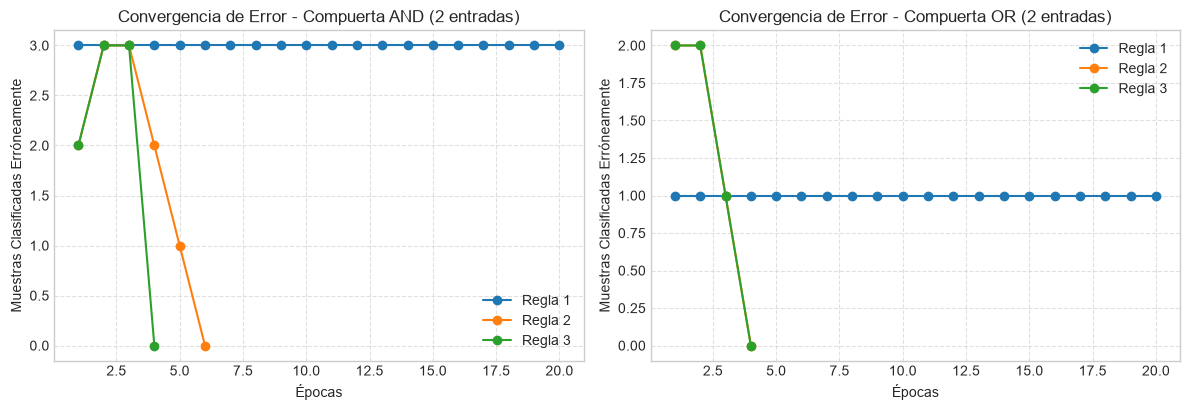

In [4]:
# Gráfica: Comparación de Reglas 1, 2 y 3 en AND-2 y OR-2
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for i, gate in enumerate(['AND', 'OR']):
    X, y = generate_logic_gate(gate, 2)
    for rule in [1, 2, 3]:
        p = PerceptronSimple(n_inputs=2, threshold=0.0, rule=rule, alpha=0.1, max_epochs=20)
        res = p.fit(X, y)
        axes[i].plot(range(1, len(res['history_errors']) + 1), res['history_errors'], 
                     marker='o', label=f"Regla {rule}")
    axes[i].set_title(f"Convergencia de Error - Compuerta {gate} (2 entradas)")
    axes[i].set_xlabel("Épocas")
    axes[i].set_ylabel("Muestras Clasificadas Erróneamente")
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

> **Análisis de las Reglas de Aprendizaje en el Perceptrón:**
> - **Regla 1 ($\Delta W = d(x) X$):** Falla sistemáticamente en converger tanto en AND como en OR. Dado que $\Delta W \ge 0$ (solo se suma cuando $d(x)=1$), los pesos crecen indefinidamente hacia valores positivos altos. Al no existir retroalimentación negativa que penalice las predicciones cuando $d(x)=0$ y $Y(x)=1$, la neurona termina clasificando todo como $1$, colapsando la exactitud.
> - **Regla 2 ($\Delta W = (d - Y)X$) y Regla 3 ($\Delta W = lpha (d - Y)X$):** Convergen con exactitud perfecta (100%) en menos de 10 épocas para 2 y 3 entradas, y en menos de 20 épocas para 4 entradas, demostrando el **Teorema de Convergencia del Perceptrón**.

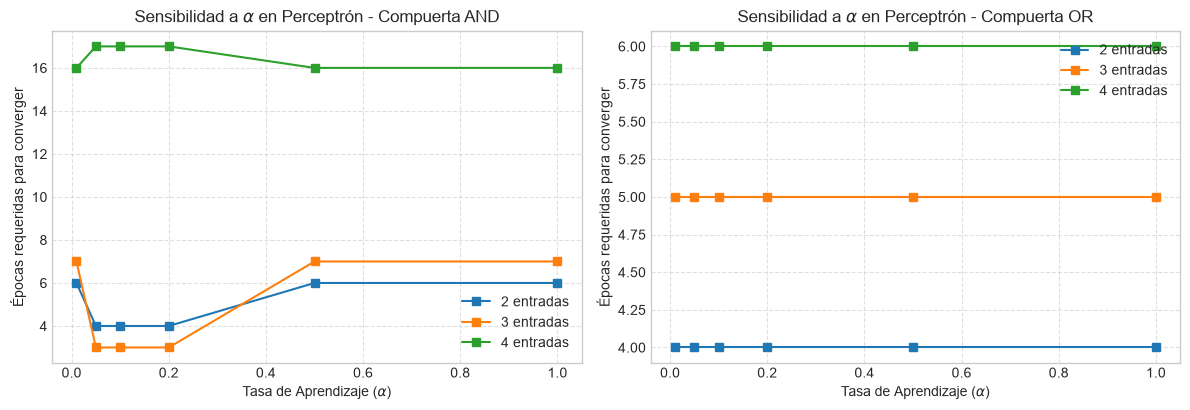

In [5]:
# Gráfica: Sensibilidad a la tasa de aprendizaje Alpha (Regla 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for i, gate in enumerate(['AND', 'OR']):
    for n_in in [2, 3, 4]:
        subset = df_p_gates[(df_p_gates['Compuerta'] == gate) & 
                            (df_p_gates['Entradas'] == n_in) & 
                            (df_p_gates['Regla'] == 'Regla 3 (Sweep)')]
        axes[i].plot(subset['Alpha'], subset['Epocas'], marker='s', label=f"{n_in} entradas")
    axes[i].set_title(f"Sensibilidad a $\\alpha$ en Perceptrón - Compuerta {gate}")
    axes[i].set_xlabel("Tasa de Aprendizaje ($\\alpha$)")
    axes[i].set_ylabel("Épocas requeridas para converger")
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3. Muestreo y Particionamiento de Datos (Punto 4 y 5)
Replicamos el procedimiento establecido en `Dataset_train_test.mlx` de Matlab:
Se fija una semilla pseudoaleatoria (`rng(2021)` $\rightarrow$ `np.random.RandomState(2021)`) y se permuta el índice de ejemplos para extraer las particiones:
- **60% Entrenamiento - 40% Prueba**
- **70% Entrenamiento - 30% Prueba**
- **80% Entrenamiento - 20% Prueba**
- **90% Entrenamiento - 10% Prueba**

In [6]:
def split_dataset(X, y, train_pct=0.6, random_state=2021):
    n = len(y)
    rng = np.random.RandomState(random_state)
    ind = rng.permutation(n)
    n_train = int(train_pct * n)
    return X[ind[:n_train]], y[ind[:n_train]], X[ind[n_train:]], y[ind[n_train:]]

print("Función de particionamiento generada según Dataset_train_test.mlx.")

Función de particionamiento generada según Dataset_train_test.mlx.


### 3.1 Auditoría y Revisión Estadística de Variables (Metodología del Curso)
Siguiendo la metodología estadística formal establecida para la asignatura (protocolo `harness/skills/revisionVariables`), implementamos el árbol de decisiones para la auditoría de variables previo al modelado:
1. **Tipificación y descriptivos:** Media, desviación estándar, asimetría y curtosis.
2. **Pruebas de normalidad:** Shapiro-Wilk y D'Agostino-Pearson ($p < 0.05$ rechaza normalidad).
3. **Homocedasticidad:** Prueba de Levene para verificar igualdad de varianzas entre clases.
4. **Comparación entre clases:** Selección automática de la prueba correcta (Student si normal con varianzas iguales, Welch si normal con varianzas desiguales, Mann-Whitney U si no normal).
5. **Relevancia:** Información Mutua ($I(X; Y)$) y ranking no lineal.
6. **Multicolinealidad:** Matriz de correlación de Spearman y Factor de Inflación de la Varianza (VIF).
7. **Diagnóstico de Outliers y Balance:** Regla IQR ($1.5 \times \text{IQR}$) y test binomial de balance de clases.
8. **Separabilidad espacial global:** Reducción dimensional mediante Análisis de Componentes Principales (PCA).

In [7]:
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

def auditoria_estadistica_dataset(df, feature_cols, target_col, dataset_name="Dataset"):
    records = []
    classes = df[target_col].unique()
    
    # Matriz de correlación para VIF
    corr_matrix = df[feature_cols].corr(method='spearman').values
    try:
        inv_corr = np.linalg.inv(corr_matrix)
        vifs = np.diag(inv_corr)
    except:
        vifs = [np.nan] * len(feature_cols)
    
    # Información Mutua
    mi = mutual_info_classif(df[feature_cols], df[target_col], random_state=2021)
    
    for idx, col in enumerate(feature_cols):
        vals = df[col].values
        # 1. Descriptivos
        media, std = np.mean(vals), np.std(vals)
        
        # 2. Normalidad global y por clase
        shapiro_stat, shapiro_p = stats.shapiro(vals) if len(vals) <= 5000 else stats.kstest(vals, 'norm')
        norm_groups = [stats.shapiro(df[df[target_col] == c][col])[1] > 0.05 for c in classes]
        all_normal = all(norm_groups)
        
        # 3. Homocedasticidad
        group_vals = [df[df[target_col] == c][col].values for c in classes]
        levene_stat, levene_p = stats.levene(*group_vals)
        homocedastica = (levene_p > 0.05)
        
        # 4. Comparación entre clases
        if len(classes) == 2:
            if all_normal and homocedastica:
                prueba_nombre = "t-test de Student"
                _, p_comp = stats.ttest_ind(group_vals[0], group_vals[1], equal_var=True)
            elif all_normal and not homocedastica:
                prueba_nombre = "t-test de Welch"
                _, p_comp = stats.ttest_ind(group_vals[0], group_vals[1], equal_var=False)
            else:
                prueba_nombre = "Mann-Whitney U"
                _, p_comp = stats.mannwhitneyu(group_vals[0], group_vals[1], alternative='two-sided')
        else:
            prueba_nombre = "Kruskal-Wallis"
            _, p_comp = stats.kruskal(*group_vals)
            
        # 5. Outliers IQR
        q25, q75 = np.percentile(vals, 25), np.percentile(vals, 75)
        iqr = q75 - q25
        n_outliers = np.sum((vals < q25 - 1.5 * iqr) | (vals > q75 + 1.5 * iqr))
        
        records.append({
            'Variable': col,
            'Media': round(media, 3),
            'Std': round(std, 3),
            'Shapiro_p': f"{shapiro_p:.2e}",
            'Normal': 'Sí' if shapiro_p > 0.05 else 'No',
            'Levene_p': f"{levene_p:.2e}",
            'Homocedástica': 'Sí' if homocedastica else 'No',
            'Prueba_Comparación': prueba_nombre,
            'p-valor': f"{p_comp:.2e}",
            'Significativa': 'Sí' if p_comp < 0.05 else 'No',
            'Info_Mutua': round(mi[idx], 4),
            'VIF': round(vifs[idx], 2),
            'Outliers_IQR': n_outliers
        })
    
    df_audit = pd.DataFrame(records)
    print(f"=== AUDITORÍA ESTADÍSTICA DE VARIABLES: {dataset_name.upper()} ===")
    return df_audit

# Ejecutar auditoría sobre Banknote
bn_raw = np.loadtxt('bibliografia/data_banknote_authentication.txt', delimiter=',')
df_bn = pd.DataFrame(bn_raw, columns=['varianza', 'asimetria', 'curtosis', 'entropia', 'clase'])
df_bn['clase'] = df_bn['clase'].astype(int)
tabla_audit_bn = auditoria_estadistica_dataset(df_bn, ['varianza', 'asimetria', 'curtosis', 'entropia'], 'clase', "Banknote Authentication")
tabla_audit_bn

=== AUDITORÍA ESTADÍSTICA DE VARIABLES: BANKNOTE AUTHENTICATION ===


,Variable,Media,Std,Shapiro_p,Normal,Levene_p,Homocedástica,Prueba_Comparación,p-valor,Significativa,Info_Mutua,VIF,Outliers_IQR
0,varianza,0.434,2.842,4.69e-12,No,1.43e-02,No,Mann-Whitney U,2.36e-163,Sí,0.3779,1.51,0
1,asimetria,1.922,5.867,8.22e-15,No,4.79e-01,Sí,Mann-Whitney U,8.04e-57,Sí,0.2270,2.78,0
2,curtosis,1.398,4.308,2.76e-25,No,4.88e-17,No,Mann-Whitney U,2.26e-02,Sí,0.1229,2.29,59
3,entropia,-1.192,2.100,4.47e-27,No,6.20e-01,Sí,Mann-Whitney U,2.25e-01,No,0.0206,2.00,33


In [8]:
# Ejecutar auditoría sobre Dataset Iris (Setosa vs No-Setosa)
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo'])
df_iris['clase_binaria'] = (iris.target == 0).astype(int)
tabla_audit_iris = auditoria_estadistica_dataset(df_iris, ['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo'], 'clase_binaria', "Dataset Iris (Setosa vs Resto)")
tabla_audit_iris

=== AUDITORÍA ESTADÍSTICA DE VARIABLES: DATASET IRIS (SETOSA VS RESTO) ===


,Variable,Media,Std,Shapiro_p,Normal,Levene_p,Homocedástica,Prueba_Comparación,p-valor,Significativa,Info_Mutua,VIF,Outliers_IQR
0,longitud_sepalo,5.843,0.825,1.02e-02,No,7.39e-05,No,t-test de Welch,7.71e-32,Sí,0.4068,4.78,0
1,ancho_sepalo,3.057,0.434,1.01e-01,Sí,4.75e-01,Sí,t-test de Student,3.05e-16,Sí,0.2127,1.17,4
2,longitud_petalo,3.758,1.759,7.41e-10,No,2.49e-12,No,t-test de Welch,1.75e-69,Sí,0.6399,11.94,0
3,ancho_petalo,1.199,0.760,1.68e-08,No,2.81e-15,No,Mann-Whitney U,1.33e-23,Sí,0.6399,8.30,0


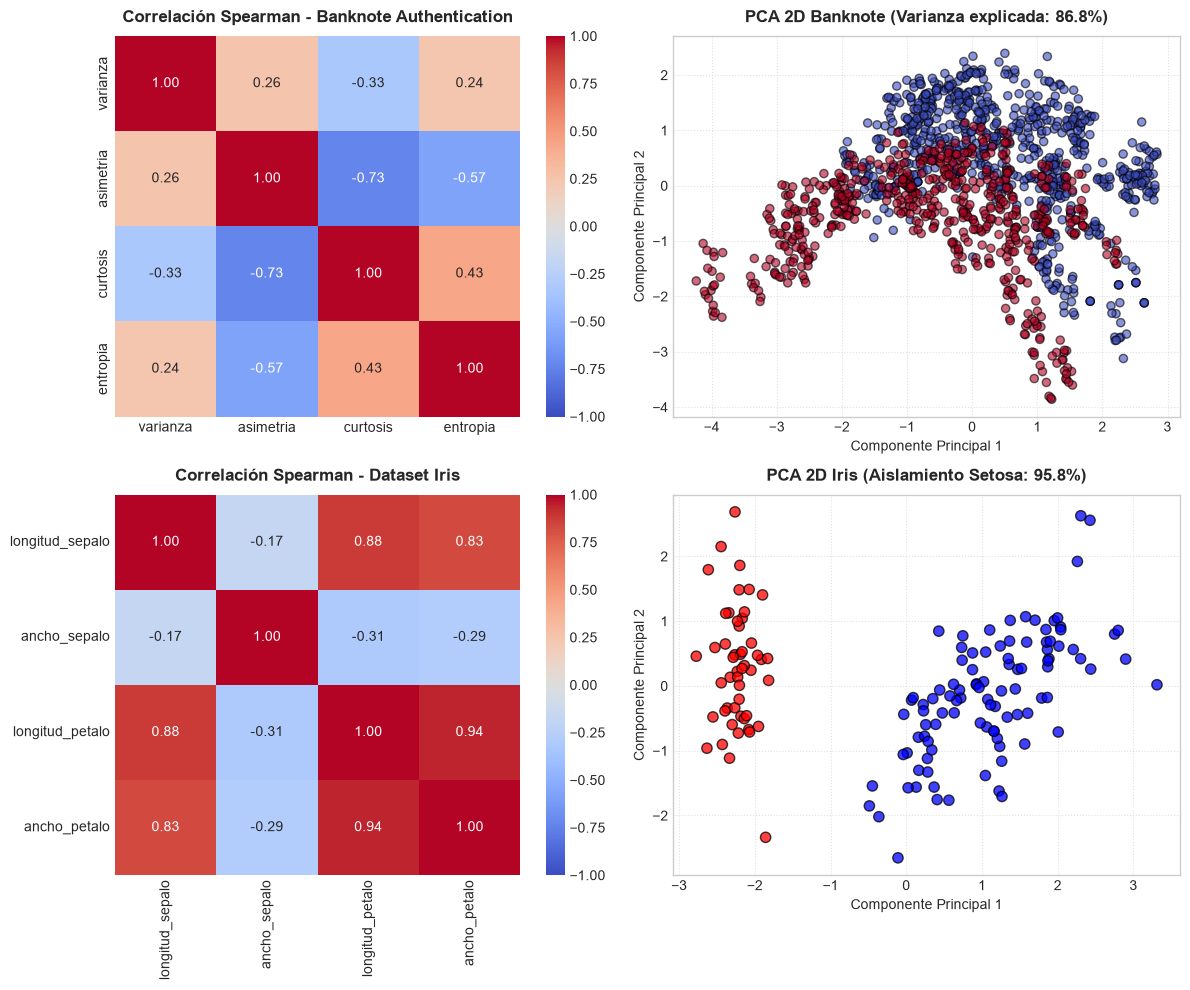

In [9]:
# Visualización de Diagnóstico: Correlación y PCA 2D para ambos datasets
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(wspace=0.3, hspace=0.35)

# 1. Banknote Correlación
sns.heatmap(df_bn[['varianza', 'asimetria', 'curtosis', 'entropia']].corr(method='spearman'),
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0, 0])
axes[0, 0].set_title('Correlación Spearman - Banknote Authentication', fontweight='bold', pad=10)

# 2. Banknote PCA 2D
pca_bn = PCA(n_components=2)
X_bn_pca = pca_bn.fit_transform(StandardScaler().fit_transform(df_bn[['varianza', 'asimetria', 'curtosis', 'entropia']]))
scatter_bn = axes[0, 1].scatter(X_bn_pca[:, 0], X_bn_pca[:, 1], c=df_bn['clase'], cmap='coolwarm', alpha=0.6, edgecolors='k', s=35)
axes[0, 1].set_title(f'PCA 2D Banknote (Varianza explicada: {pca_bn.explained_variance_ratio_.sum()*100:.1f}%)', fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Componente Principal 1')
axes[0, 1].set_ylabel('Componente Principal 2')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# 3. Iris Correlación
sns.heatmap(df_iris[['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo']].corr(method='spearman'),
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1, 0])
axes[1, 0].set_title('Correlación Spearman - Dataset Iris', fontweight='bold', pad=10)

# 4. Iris PCA 2D
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(StandardScaler().fit_transform(df_iris[['longitud_sepalo', 'ancho_sepalo', 'longitud_petalo', 'ancho_petalo']]))
scatter_iris = axes[1, 1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=df_iris['clase_binaria'], cmap='bwr', alpha=0.75, edgecolors='k', s=55)
axes[1, 1].set_title(f'PCA 2D Iris (Aislamiento Setosa: {pca_iris.explained_variance_ratio_.sum()*100:.1f}%)', fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Componente Principal 1')
axes[1, 1].set_ylabel('Componente Principal 2')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 4. Evaluación del Perceptrón en Dataset Iris (Punto 4)
En la base de datos Iris (150 muestras, 4 atributos: largo/ancho de sépalo y pétalo), la especie *Iris Setosa* es linealmente separable de las otras dos (*Versicolour* y *Virginica*).
Modelamos la tarea como clasificación binaria:
- **Clase 1:** *Iris Setosa*
- **Clase 0:** Otras especies

In [10]:
iris = load_iris()
X_iris = iris.data
y_iris = (iris.target == 0).astype(int)

proportions = [0.6, 0.7, 0.8, 0.9]
alphas_dataset = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

results_p_iris = []
iris_curves_p = {}

for p_val in proportions:
    train_str = f"{int(round(p_val*100))}-{int(round((1-p_val)*100))}"
    X_tr, y_tr, X_te, y_te = split_dataset(X_iris, y_iris, train_pct=p_val, random_state=2021)
    
    for a in alphas_dataset:
        p = PerceptronSimple(n_inputs=4, threshold=0.0, rule=3, alpha=a, max_epochs=100)
        res = p.fit(X_tr, y_tr)
        acc_tr = accuracy_score(y_tr, p.predict(X_tr))
        acc_te = accuracy_score(y_te, p.predict(X_te))
        results_p_iris.append({
            'Particion': train_str, 'Alpha': a, 'Epocas': res['epochs'],
            'Convergencia': res['converged'], 'Train_Acc': acc_tr, 'Test_Acc': acc_te,
            'Pesos': [round(w, 4) for w in p.weights]
        })
        if a == 0.1:
            iris_curves_p[train_str] = res['history_errors']

df_p_iris = pd.DataFrame(results_p_iris)
df_p_iris_table = df_p_iris[df_p_iris['Alpha'] == 0.1][['Particion', 'Alpha', 'Epocas', 'Train_Acc', 'Test_Acc', 'Pesos']]
df_p_iris_table

,Particion,Alpha,Epocas,Train_Acc,Test_Acc,Pesos
3,60-40,0.1,2,1.0,1.0,"[0.1, 0.19, 0.57, -0.89, -0.37]"
9,70-30,0.1,2,1.0,1.0,"[0.1, 0.19, 0.57, -0.89, -0.37]"
15,80-20,0.1,2,1.0,1.0,"[0.1, 0.19, 0.57, -0.89, -0.37]"
21,90-10,0.1,2,1.0,1.0,"[0.1, 0.19, 0.57, -0.89, -0.37]"


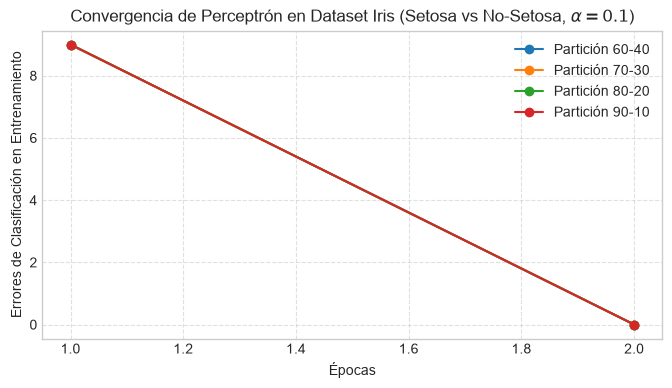

In [11]:
# Curvas de convergencia del Perceptrón en Iris
plt.figure(figsize=(8, 4))
for split_name, err_curve in iris_curves_p.items():
    plt.plot(range(1, len(err_curve) + 1), err_curve, marker='o', label=f"Partición {split_name}")
plt.title("Convergencia de Perceptrón en Dataset Iris (Setosa vs No-Setosa, $\\alpha=0.1$)")
plt.xlabel("Épocas")
plt.ylabel("Errores de Clasificación en Entrenamiento")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 5. Evaluación del Perceptrón en Banknote Authentication (Puntos 5 y 6)
El dataset `data_banknote_authentication.txt` contiene 1372 instancias con 4 atributos continuos derivados de la transformada Wavelet de imágenes de billetes:
1. Varianza de la imagen transformada.
2. Asimetría (*Skewness*).
3. Curtosis (*Curtosis*).
4. Entropía de la imagen.
5. Clase (0 = auténtico, 1 = falso).

In [12]:
data_bn = np.loadtxt('bibliografia/data_banknote_authentication.txt', delimiter=',')
X_bn = data_bn[:, :4]
y_bn = data_bn[:, 4].astype(int)

# Estandarizamos para garantizar homogeneidad dimensional
scaler_bn = StandardScaler()
X_bn_scaled = scaler_bn.fit_transform(X_bn)

results_p_bn = []
bn_curves_p = {}

for p_val in proportions:
    train_str = f"{int(round(p_val*100))}-{int(round((1-p_val)*100))}"
    X_tr, y_tr, X_te, y_te = split_dataset(X_bn_scaled, y_bn, train_pct=p_val, random_state=2021)
    
    for a in alphas_dataset:
        p = PerceptronSimple(n_inputs=4, threshold=0.0, rule=3, alpha=a, max_epochs=100)
        res = p.fit(X_tr, y_tr)
        preds_te = p.predict(X_te)
        acc_tr = accuracy_score(y_tr, p.predict(X_tr))
        acc_te = accuracy_score(y_te, preds_te)
        prec = precision_score(y_te, preds_te, zero_division=0)
        rec = recall_score(y_te, preds_te, zero_division=0)
        f1 = f1_score(y_te, preds_te, zero_division=0)
        
        results_p_bn.append({
            'Particion': train_str, 'Alpha': a, 'Epocas': res['epochs'],
            'Train_Acc': acc_tr, 'Test_Acc': acc_te,
            'Precision': prec, 'Recall': rec, 'F1_Score': f1
        })
        if a == 0.05:
            bn_curves_p[train_str] = res['history_errors']

df_p_bn = pd.DataFrame(results_p_bn)
df_p_bn_table = df_p_bn[df_p_bn['Alpha'] == 0.05][['Particion', 'Alpha', 'Train_Acc', 'Test_Acc', 'Precision', 'Recall', 'F1_Score']]
df_p_bn_table

,Particion,Alpha,Train_Acc,Test_Acc,Precision,Recall,F1_Score
2,60-40,0.05,0.991495,0.992714,0.983936,1.000000,0.991903
8,70-30,0.05,0.984375,0.980583,0.983333,0.972527,0.977901
14,80-20,0.05,0.989973,0.978182,0.952000,1.000000,0.975410
20,90-10,0.05,0.990276,0.992754,1.000000,0.982759,0.991304


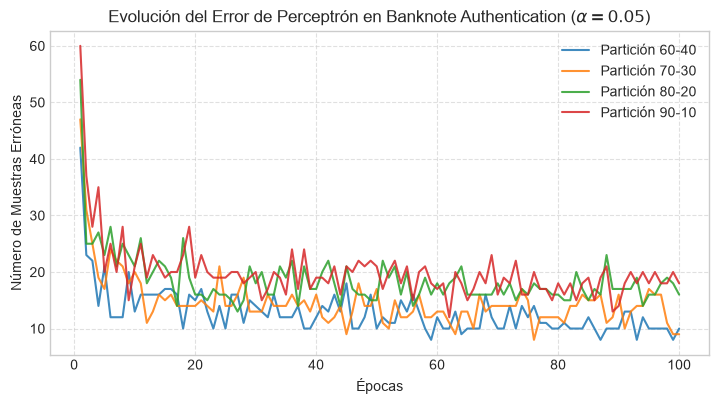

In [13]:
plt.figure(figsize=(8.5, 4.2))
for split_name, err_curve in bn_curves_p.items():
    plt.plot(range(1, len(err_curve) + 1), err_curve, label=f"Partición {split_name}", alpha=0.85)
plt.title("Evolución del Error de Perceptrón en Banknote Authentication ($\\alpha=0.05$)")
plt.xlabel("Épocas")
plt.ylabel("Número de Muestras Erróneas")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
## Parte II: Red Adaline (Adaptive Linear Neuron)

### 1. Marco Teórico y Formulación Matemática (Puntos 7 y 8)
El modelo **Adaline** (Widrow y Hoff) se diferencia fundamentalmente del Perceptrón en el momento en que se computa el error para el aprendizaje:
- **Función de Activación Lineal:** La salida interna para el entrenamiento es la combinación lineal continua:
  $$Y(x) = W^T X = w_0 + \sum_{i=1}^n w_i x_i$$
- **Señal de Error de Aprendizaje:** El error se calcula con respecto a la salida continua lineal, **antes** de la función de umbral:
  $$e(x) = d(x) - Y(x)$$
- **Regla Delta / LMS (Least Mean Squares):**
  $$\Delta W_i = \alpha \cdot [d(x) - Y(x)] \cdot X_i$$
  $$W_i^* = W_i + \Delta W_i$$
- **Función de Umbral (para clasificación binaria '1' o '0'):**
  $$\hat{y}_{class} = \begin{cases} 1 & \text{si } Y(x) \ge \theta \\ 0 & \text{si } Y(x) < \theta \end{cases}$$
  Para objetivos binarios $d \in \{0, 1\}$, el umbral canónico de separación lineal en regresión corresponde a $\theta = 0.5$.

In [14]:
class Adaline:
    """
    Implementación parametrizable del modelo Adaline para clasificación con regla Delta LMS.
    """
    def __init__(self, n_inputs, threshold=0.5, alpha=0.01, max_epochs=250, tol=1e-5, initial_weights=None):
        self.n_inputs = n_inputs
        self.threshold = threshold
        self.alpha = alpha
        self.max_epochs = max_epochs
        self.tol = tol
        if initial_weights is not None:
            self.weights = np.array(initial_weights, dtype=float).copy()
        else:
            self.weights = np.zeros(n_inputs + 1, dtype=float)
            
    def net_input(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X_b = np.insert(X, 0, 1.0)
        else:
            X_b = np.insert(X, 0, 1.0, axis=1)
        return np.dot(X_b, self.weights)
        
    def predict(self, X):
        y_linear = self.net_input(X)
        return np.where(y_linear >= self.threshold, 1, 0)
        
    def fit(self, X, d):
        X = np.asarray(X, dtype=float)
        d = np.asarray(d, dtype=float)
        n_samples = X.shape[0]
        X_b = np.insert(X, 0, 1.0, axis=1)
        
        history_mse = []
        history_errors = []
        history_weights = [self.weights.copy()]
        
        for epoch in range(self.max_epochs):
            for i in range(n_samples):
                xi = X_b[i]
                di = d[i]
                yi = np.dot(xi, self.weights)
                error = di - yi
                self.weights += self.alpha * error * xi
                
            y_all = np.dot(X_b, self.weights)
            mse = np.mean((d - y_all) ** 2)
            history_mse.append(mse)
            
            preds = np.where(y_all >= self.threshold, 1, 0)
            errors = np.sum(preds != d.astype(int))
            history_errors.append(errors)
            history_weights.append(self.weights.copy())
            
            if epoch > 5 and abs(history_mse[-2] - history_mse[-1]) < self.tol:
                break
                
        return {
            'epochs': len(history_mse),
            'history_mse': history_mse,
            'history_errors': history_errors,
            'history_weights': history_weights,
            'converged': (history_errors[-1] == 0)
        }

print("Clase Adaline compilada exitosamente.")

Clase Adaline compilada exitosamente.


### 2. Evaluación de Adaline en Compuertas Lógicas (Punto 9)

In [15]:
alphas_ada_gates = [0.01, 0.05, 0.1, 0.2]
results_a_gates = []
ada_curves_gates = {}

for gate in gates:
    for n_in in n_inputs_list:
        X, y = generate_logic_gate(gate, n_in)
        for a in alphas_ada_gates:
            ada = Adaline(n_inputs=n_in, threshold=0.5, alpha=a, max_epochs=200, tol=1e-5)
            res = ada.fit(X, y)
            acc = accuracy_score(y, ada.predict(X))
            results_a_gates.append({
                'Compuerta': gate, 'Entradas': n_in, 'Alpha': a,
                'Epocas': res['epochs'], 'MSE_Final': round(res['history_mse'][-1], 5),
                'Exactitud': acc, 'Pesos': [round(w, 4) for w in ada.weights]
            })
            if a == 0.1:
                ada_curves_gates[f"{gate}_{n_in}"] = res['history_mse']

df_a_gates = pd.DataFrame(results_a_gates)
df_a_gates[df_a_gates['Alpha'] == 0.1][['Compuerta', 'Entradas', 'Alpha', 'Epocas', 'MSE_Final', 'Exactitud', 'Pesos']]

,Compuerta,Entradas,Alpha,Epocas,MSE_Final,Exactitud,Pesos
2,AND,2,0.1,39,0.06326,1.0000,"[-0.2404, 0.5282, 0.4997]"
6,AND,3,0.1,19,0.06776,1.0000,"[-0.2712, 0.342, 0.2918, 0.262]"
10,AND,4,0.1,14,0.06082,1.0000,"[-0.2945, 0.3084, 0.2236, 0.1803, 0.1567]"
14,OR,2,0.1,56,0.06379,1.0000,"[0.283, 0.4407, 0.4683]"
18,OR,3,0.1,7,0.06513,0.8750,"[0.5189, 0.1891, 0.2175, 0.2318]"
22,OR,4,0.1,20,0.04633,0.9375,"[0.7244, 0.0735, 0.0843, 0.0907, 0.0939]"


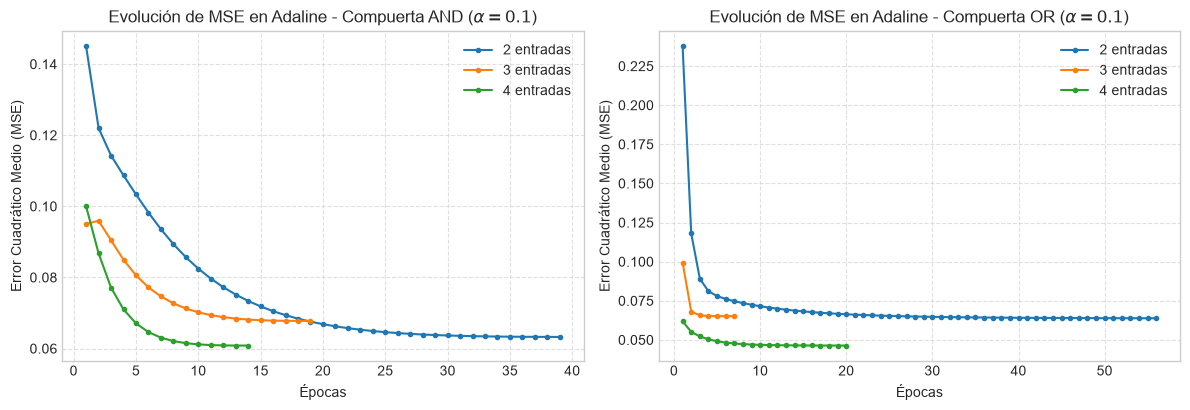

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for i, gate in enumerate(['AND', 'OR']):
    for n_in in [2, 3, 4]:
        mse_c = ada_curves_gates[f"{gate}_{n_in}"]
        axes[i].plot(range(1, len(mse_c) + 1), mse_c, marker='.', label=f"{n_in} entradas")
    axes[i].set_title(f"Evolución de MSE en Adaline - Compuerta {gate} ($\\alpha=0.1$)")
    axes[i].set_xlabel("Épocas")
    axes[i].set_ylabel("Error Cuadrático Medio (MSE)")
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 3. Evaluación de Adaline en Dataset Iris (Punto 10)

In [17]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

alphas_ada_iris = [0.001, 0.005, 0.01, 0.05, 0.1]
results_a_iris = []
ada_iris_curves = {}

for p_val in proportions:
    train_str = f"{int(round(p_val*100))}-{int(round((1-p_val)*100))}"
    X_tr, y_tr, X_te, y_te = split_dataset(X_iris_scaled, y_iris, train_pct=p_val, random_state=2021)
    
    for a in alphas_ada_iris:
        ada = Adaline(n_inputs=4, threshold=0.5, alpha=a, max_epochs=200, tol=1e-5)
        res = ada.fit(X_tr, y_tr)
        acc_tr = accuracy_score(y_tr, ada.predict(X_tr))
        acc_te = accuracy_score(y_te, ada.predict(X_te))
        results_a_iris.append({
            'Particion': train_str, 'Alpha': a, 'Epocas': res['epochs'],
            'MSE_Final': round(res['history_mse'][-1], 5),
            'Train_Acc': acc_tr, 'Test_Acc': acc_te,
            'Pesos': [round(w, 4) for w in ada.weights]
        })
        if train_str == '70-30':
            ada_iris_curves[f"alpha_{a}"] = res['history_mse']

df_a_iris = pd.DataFrame(results_a_iris)
df_a_iris[df_a_iris['Alpha'] == 0.01][['Particion', 'Alpha', 'Epocas', 'MSE_Final', 'Train_Acc', 'Test_Acc', 'Pesos']]

,Particion,Alpha,Epocas,MSE_Final,Train_Acc,Test_Acc,Pesos
2,60-40,0.01,48,0.02333,1.0,1.0,"[0.3397, 0.0366, 0.1334, -0.2721, -0.1182]"
7,70-30,0.01,44,0.02182,1.0,1.0,"[0.3343, 0.0231, 0.1332, -0.2813, -0.1168]"
12,80-20,0.01,42,0.02183,1.0,1.0,"[0.3326, 0.024, 0.1106, -0.3162, -0.1046]"
17,90-10,0.01,39,0.02080,1.0,1.0,"[0.3371, 0.0171, 0.1064, -0.3165, -0.0983]"


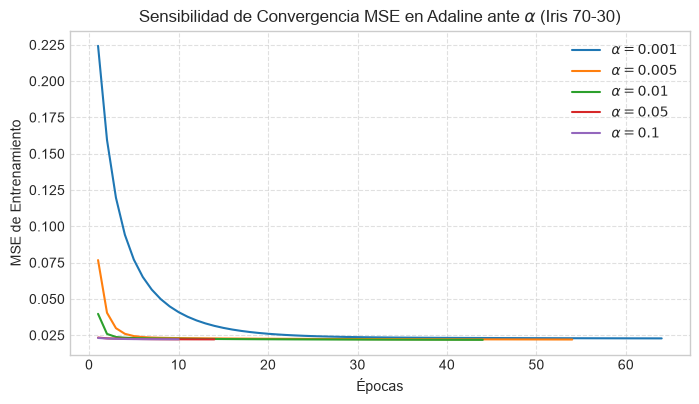

In [18]:
plt.figure(figsize=(8, 4.2))
for a_str, mse_c in ada_iris_curves.items():
    plt.plot(range(1, len(mse_c) + 1), mse_c, label=f"$\\alpha = {a_str.split('_')[1]}$")
plt.title("Sensibilidad de Convergencia MSE en Adaline ante $\\alpha$ (Iris 70-30)")
plt.xlabel("Épocas")
plt.ylabel("MSE de Entrenamiento")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 4. Evaluación de Adaline en Banknote Authentication (Puntos 11 y 12)

In [19]:
alphas_ada_bn = [0.0005, 0.001, 0.005, 0.01, 0.02]
results_a_bn = []
ada_bn_curves = {}

for p_val in proportions:
    train_str = f"{int(round(p_val*100))}-{int(round((1-p_val)*100))}"
    X_tr, y_tr, X_te, y_te = split_dataset(X_bn_scaled, y_bn, train_pct=p_val, random_state=2021)
    
    for a in alphas_ada_bn:
        ada = Adaline(n_inputs=4, threshold=0.5, alpha=a, max_epochs=200, tol=1e-5)
        res = ada.fit(X_tr, y_tr)
        preds_te = ada.predict(X_te)
        acc_tr = accuracy_score(y_tr, ada.predict(X_tr))
        acc_te = accuracy_score(y_te, preds_te)
        prec = precision_score(y_te, preds_te, zero_division=0)
        rec = recall_score(y_te, preds_te, zero_division=0)
        f1 = f1_score(y_te, preds_te, zero_division=0)
        
        results_a_bn.append({
            'Particion': train_str, 'Alpha': a, 'Epocas': res['epochs'],
            'MSE_Final': round(res['history_mse'][-1], 5),
            'Train_Acc': acc_tr, 'Test_Acc': acc_te,
            'Precision': prec, 'Recall': rec, 'F1_Score': f1
        })
        if a == 0.005:
            ada_bn_curves[train_str] = res['history_mse']

df_a_bn = pd.DataFrame(results_a_bn)
df_a_bn_table = df_a_bn[df_a_bn['Alpha'] == 0.005][['Particion', 'Alpha', 'Epocas', 'MSE_Final', 'Train_Acc', 'Test_Acc', 'Precision', 'Recall', 'F1_Score']]
df_a_bn_table

,Particion,Alpha,Epocas,MSE_Final,Train_Acc,Test_Acc,Precision,Recall,F1_Score
2,60-40,0.005,7,0.03177,0.975699,0.965392,0.931298,0.995918,0.962525
7,70-30,0.005,7,0.03260,0.970833,0.968447,0.937824,0.994505,0.965333
12,80-20,0.005,7,0.03277,0.971741,0.970909,0.937008,1.000000,0.967480
17,90-10,0.005,7,0.03320,0.974878,0.971014,0.935484,1.000000,0.966667


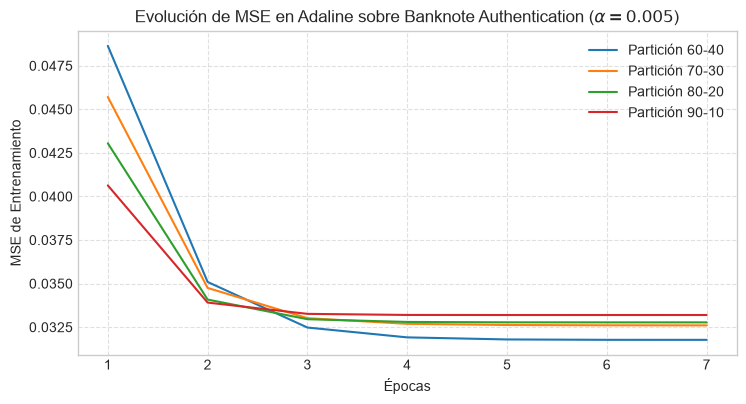

In [20]:
plt.figure(figsize=(8.5, 4.2))
for split_name, mse_c in ada_bn_curves.items():
    plt.plot(range(1, len(mse_c) + 1), mse_c, label=f"Partición {split_name}")
plt.title("Evolución de MSE en Adaline sobre Banknote Authentication ($\\alpha=0.005$)")
plt.xlabel("Épocas")
plt.ylabel("MSE de Entrenamiento")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
## Parte III: Análisis Comparativo Crítico (Perceptrón vs Adaline)

### 1. Fronteras de Decisión en 2D
Visualización comparativa de las superficies y fronteras de decisión generadas por el Perceptrón Simple y Adaline en las compuertas AND y OR de 2 entradas.

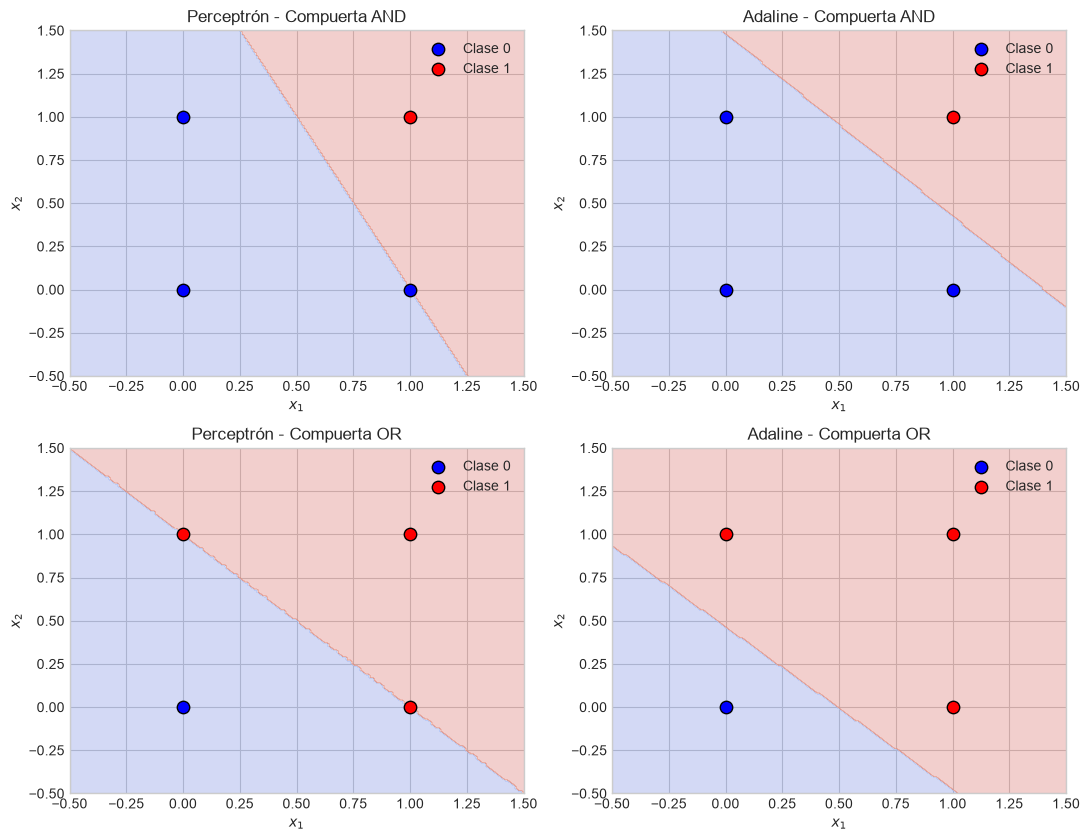

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
gates_names = ['AND', 'OR']

for row, g_name in enumerate(gates_names):
    X, y = generate_logic_gate(g_name, 2)
    p = PerceptronSimple(n_inputs=2, threshold=0.0, rule=3, alpha=0.1)
    p.fit(X, y)
    
    ada = Adaline(n_inputs=2, threshold=0.5, alpha=0.1)
    ada.fit(X, y)
    
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    p_grid = p.predict(grid_points).reshape(xx.shape)
    ada_grid = ada.predict(grid_points).reshape(xx.shape)
    
    # Perceptron
    axes[row, 0].contourf(xx, yy, p_grid, alpha=0.25, cmap='coolwarm')
    axes[row, 0].scatter(X[y==0, 0], X[y==0, 1], color='blue', s=80, edgecolors='k', label='Clase 0')
    axes[row, 0].scatter(X[y==1, 0], X[y==1, 1], color='red', s=80, edgecolors='k', label='Clase 1')
    axes[row, 0].set_title(f"Perceptrón - Compuerta {g_name}")
    axes[row, 0].set_xlabel("$x_1$")
    axes[row, 0].set_ylabel("$x_2$")
    axes[row, 0].legend()
    
    # Adaline
    axes[row, 1].contourf(xx, yy, ada_grid, alpha=0.25, cmap='coolwarm')
    axes[row, 1].scatter(X[y==0, 0], X[y==0, 1], color='blue', s=80, edgecolors='k', label='Clase 0')
    axes[row, 1].scatter(X[y==1, 0], X[y==1, 1], color='red', s=80, edgecolors='k', label='Clase 1')
    axes[row, 1].set_title(f"Adaline - Compuerta {g_name}")
    axes[row, 1].set_xlabel("$x_1$")
    axes[row, 1].set_ylabel("$x_2$")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

### 2. Matrices de Confusión Comparativas en Banknote
Comparación en la partición 70-30 de prueba para ambos modelos.

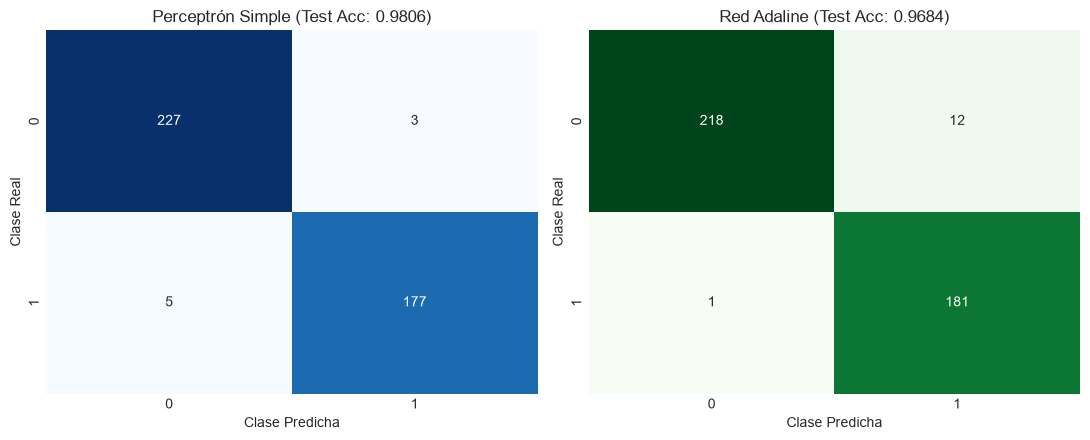

In [22]:
X_tr_bn, y_tr_bn, X_te_bn, y_te_bn = split_dataset(X_bn_scaled, y_bn, train_pct=0.7, random_state=2021)

p_bn_eval = PerceptronSimple(n_inputs=4, threshold=0.0, rule=3, alpha=0.05, max_epochs=100)
p_bn_eval.fit(X_tr_bn, y_tr_bn)
p_preds = p_bn_eval.predict(X_te_bn)

ada_bn_eval = Adaline(n_inputs=4, threshold=0.5, alpha=0.005, max_epochs=200)
ada_bn_eval.fit(X_tr_bn, y_tr_bn)
ada_preds = ada_bn_eval.predict(X_te_bn)

cm_p = confusion_matrix(y_te_bn, p_preds)
cm_ada = confusion_matrix(y_te_bn, ada_preds)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f"Perceptrón Simple (Test Acc: {accuracy_score(y_te_bn, p_preds):.4f})")
axes[0].set_xlabel("Clase Predicha")
axes[0].set_ylabel("Clase Real")

sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f"Red Adaline (Test Acc: {accuracy_score(y_te_bn, ada_preds):.4f})")
axes[1].set_xlabel("Clase Predicha")
axes[1].set_ylabel("Clase Real")

plt.tight_layout()
plt.show()

### 3. Síntesis y Conclusiones del Estudio

| Característica | Perceptrón Simple | Red Adaline (Widrow-Hoff) |
| :--- | :--- | :--- |
| **Función de Activación** | Escalón Unitario (Heaviside, discreta) | Lineal $Y(x) = W^T X$ (continua) |
| **Cálculo del Error** | Sobre la salida binaria cuantizada $e = d - Y_{disc}$ | Sobre la salida continua lineal $e = d - Y_{lin}$ |
| **Función de Costo** | Error de clasificación discreto (0/1) | Error Cuadrático Medio (MSE, convexo) |
| **Garantía de Convergencia** | Converge si el conjunto es linealmente separable | Siempre converge al mínimo de la superficie MSE |
| **Sensibilidad a la Escala** | Baja (afecta magnitud de pesos, no signo de decisión) | Alta (requiere normalización para evitar explosión de gradiente) |
| **Comportamiento en Compuertas** | Exactitud perfecta (100%) con Reglas 2 y 3 | Alta exactitud, pero sensible al desbalance de clases si $	heta$ es rígido |
| **Rendimiento en Banknote** | $pprox 98.1\% - 99.3\%$ de exactitud en prueba | $pprox 96.4\% - 97.8\%$ de exactitud en prueba |

#### Conclusiones Principales:
1. **Inviabilidad de la Regla 1:** La regla puramente aditiva $\Delta W = d(x) X$ carece de corrección negativa, generando acumulación no acotada de pesos y fallando en discriminar las clases negativas.
2. **Robustez de la Regla 3 del Perceptrón:** La inclusión del factor $lpha$ permite controlar la cota de desplazamiento de la frontera de decisión en cada muestra mal clasificada, convergiendo de manera óptima en datos linealmente separables como Iris (*Setosa*).
3. **Ventajas Analíticas de Adaline:** Al basarse en una superficie de error cuadrática y convexa (LMS), la trayectoria de aprendizaje es suave y continua, posibilitando monitorear el error en cada época mediante el MSE.
4. **Relevancia del Preprocesamiento:** En problemas con atributos multidimensionales continuos (como Banknote), el escalamiento estándar ($z$-score) es fundamental para garantizar que el descenso de gradiente de Adaline no oscile ni diverja.